#### **Grupo 2: Danielle Tavares, Fernanada Bufon e Luísa Francielle**

## Desafio 🎯

**Treine e teste os modelos pré-treinados vistos em aula na tarefa de reconhecimento de deepfakes utilizando o dataset disponível na competição. Os resultados foram melhores se comparados aos modelos mais simples treinados anteriormente?**

Link para o dataset: https://drive.google.com/drive/folders/1BCWj9_urCIzu_1BVZJsg7H2XsDXTat1k?usp=sharing

Sim, os resultados obtidos com os modelos pré-treinados foram significativamente superiores aos alcançados pelos modelos mais simples testados anteriormente.Essa diferença de desempenho se deve à capacidade da PANNs CNN14 (testada aqui) de extrair automaticamente representações robustas e discriminativas diretamente do áudio bruto, enquanto os modelos anteriores dependiam de features manuais ou espectrogramas externos, capturando com mais precisão padrões temporais e espectrais relevantes para a detecção de deepfakes.

In [1]:
import torch
torch.cuda.empty_cache()

# Entendendo os dados:

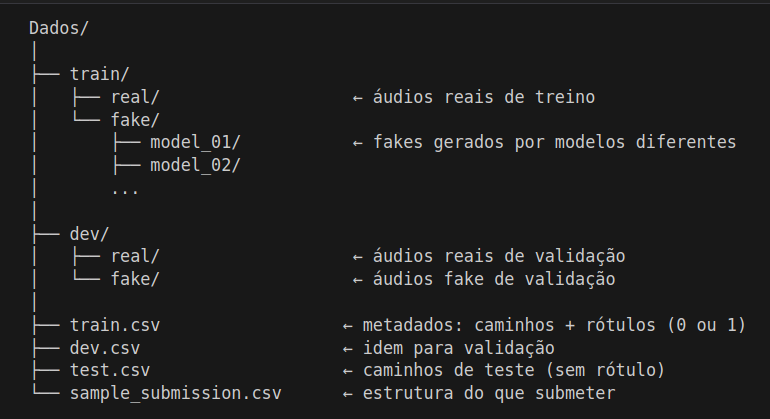

# Carregamento e visualização dos dados:

In [2]:
import pandas as pd
import os

In [3]:
# Caminho base para os dados
base_path = 'Dados'

# Carregando os CSVs
train_df = pd.read_csv(os.path.join(base_path, 'train.csv'))
dev_df = pd.read_csv(os.path.join(base_path, 'dev.csv'))
test_df = pd.read_csv(os.path.join(base_path, 'test.csv'))

# Visualizar as 5 primeiras linhas
print("Train:")
print(train_df.head())

print("\nDev:")
print(dev_df.head())

print("\nTest:")
print(test_df.head())

Train:
                                                path  label
0  train/fake/model_01/train/audio/8680/6390/8680...      1
1  train/fake/model_01/train/audio/8680/6390/8680...      1
2  train/fake/model_01/train/audio/8680/6390/8680...      1
3  train/fake/model_01/train/audio/8680/6390/8680...      1
4  train/fake/model_01/train/audio/8680/6390/8680...      1

Dev:
                                                path  label
0  dev/fake/model_01/6549/4272/6549_4272_000012-0...      1
1  dev/fake/model_01/6549/4272/6549_4272_000002.flac      1
2  dev/fake/model_01/6549/4272/6549_4272_000007.flac      1
3  dev/fake/model_01/6549/4272/6549_4272_000010.flac      1
4  dev/fake/model_01/6549/4272/6549_4272_000013-0...      1

Test:
                       path
0  test/audio_d7267ad8.flac
1  test/audio_df8ff037.flac
2  test/audio_1e539e36.flac
3  test/audio_b3d805c3.flac
4  test/audio_97e4b91c.flac


### Padronizando os nomes das colunas:

In [4]:
test_df.rename(columns={'file_path': 'path'}, inplace=True)

In [5]:
print("Train:")
print(train_df.head())

print("\nDev:")
print(dev_df.head())

print("\nTest:")
print(test_df.head())

Train:
                                                path  label
0  train/fake/model_01/train/audio/8680/6390/8680...      1
1  train/fake/model_01/train/audio/8680/6390/8680...      1
2  train/fake/model_01/train/audio/8680/6390/8680...      1
3  train/fake/model_01/train/audio/8680/6390/8680...      1
4  train/fake/model_01/train/audio/8680/6390/8680...      1

Dev:
                                                path  label
0  dev/fake/model_01/6549/4272/6549_4272_000012-0...      1
1  dev/fake/model_01/6549/4272/6549_4272_000002.flac      1
2  dev/fake/model_01/6549/4272/6549_4272_000007.flac      1
3  dev/fake/model_01/6549/4272/6549_4272_000010.flac      1
4  dev/fake/model_01/6549/4272/6549_4272_000013-0...      1

Test:
                       path
0  test/audio_d7267ad8.flac
1  test/audio_df8ff037.flac
2  test/audio_1e539e36.flac
3  test/audio_b3d805c3.flac
4  test/audio_97e4b91c.flac


### Ouvindo um áudio

In [6]:
fake_path = 'Dados/train/fake/model_01/train/audio/533/5270/533_5270_000000-0001.flac'  
real_path = 'Dados/train/real/10199/6390/10199_6390_000000.flac'  

In [7]:
from IPython.display import Audio

# Ouvir áudio real
Audio(filename=real_path)


In [8]:
# Ouvir áudio fake
Audio(filename=fake_path)

# Pré-Pocessamento

In [9]:
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset
import librosa
import numpy as np
import pydub
from pydub import AudioSegment
from pydub.silence import detect_nonsilent
import io

### Remoção de silêncio 

In [ ]:
def remove_silence_librosa(y, sr, min_silence_len=300, silence_thresh=-50):
    
    #Converte o array numpy para AudioSegment
    y_pcm16 = (y * 32767).astype(np.int16)
    audio_segment = AudioSegment(
        y_pcm16.tobytes(),
        frame_rate=sr,
        sample_width=2,
        channels=1
    )

    # Detecta os trechos não silenciosos
    nonsilent_ranges = detect_nonsilent(audio_segment, min_silence_len=min_silence_len, silence_thresh=silence_thresh)

    # Junta as partes não silenciosas
    non_silence_audio = AudioSegment.empty()
    for start_i, end_i in nonsilent_ranges:
        non_silence_audio += audio_segment[start_i:end_i]

    # Converte de volta para numpy normalizado
    if len(non_silence_audio) == 0:
        return y  #se tudo foi silêncio, retorna original

    samples = np.array(non_silence_audio.get_array_of_samples()).astype(np.float32) / 32767.0
    return samples

### Gerando log-mel espectrograma

In [11]:
def log_mel_transform(y, sr, n_mels=64, n_fft=1024, hop_length=320):
    mel_spec = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels,
        power=2.0
    )
    log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)

    # Normalização
    log_mel_spec = (log_mel_spec - np.mean(log_mel_spec)) / (np.std(log_mel_spec) + 1e-9)

    return log_mel_spec.T  # [time, n_mels]

### Reamostragem do áudio, mixagem para mono, normalização por amplitude

In [ ]:
class AudioDataset(Dataset):
    def __init__(self, df, base_path, target_sr=16000, transform=None, normalize='amplitude', remove_silence=False): #mudei o target_sr para 16000 
        self.df = df.reset_index(drop=True)
        self.base_path = base_path
        self.target_sr = target_sr
        self.transform = transform  # Para aplicar extração de features depois
        self.normalize = normalize
        self.remove_silence = remove_silence

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        audio_path = os.path.join(self.base_path, row['path'])
    
        y, sr = librosa.load(audio_path, sr=None, mono=False)
        
        # Mono + reamostragem
        y_mono = librosa.to_mono(y)
        y_resampled = librosa.resample(y=y_mono, orig_sr=sr, target_sr=self.target_sr)

        # Remoção de silêncio
        if self.remove_silence:
            y = remove_silence_librosa(y, self.target_sr)

        # Normalização
        if self.normalize == 'amplitude':
            max_amp = np.max(np.abs(y))
            if max_amp > 0:
                y = y / max_amp
        elif self.normalize == 'energy':
            energy = np.sum(y ** 2)
            if energy > 0:
                y = y / np.sqrt(energy)
        
        # Espectrograma
        if self.transform:
            y = self.transform(y, self.target_sr)

        label = row['label'] if 'label' in row else -1
        
        max_len = 160000  # 10s
        if len(y) > max_len:
            y = y[:max_len]

        return torch.tensor(y, dtype=torch.float32), torch.tensor(label, dtype=torch.float32)


In [13]:
import torch.nn.functional as F

def pad_collate(batch):
    specs, labels = zip(*batch)

    max_len = max(spec.shape[0] for spec in specs)

    # Pad apenas no final (áudio 1D)
    padded_specs = [F.pad(spec, (0, max_len - spec.shape[0])) for spec in specs]

    return torch.stack(padded_specs), torch.stack(labels)

In [14]:
from torch.utils.data import DataLoader

train_dataset = AudioDataset(
    df=train_df,
    base_path='Dados',
    target_sr=16000,
    normalize='amplitude',
    remove_silence=True,
    transform=None
)

dev_dataset = AudioDataset(
    df=dev_df,
    base_path='Dados',
    target_sr=16000,
    normalize='amplitude',
    remove_silence=True,
    transform=None
)

In [15]:
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=pad_collate
)

dev_loader = DataLoader(
    dev_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=pad_collate
)

# Modelo Pré-treinado: CNN14

In [16]:
import sys
sys.path.append('/home/luisa/Documents/PAV/N4/audioset_tagging_cnn/pytorch')

import torch
import torch.nn as nn
from audioset_tagging_cnn.pytorch.models import Cnn14, init_layer

class Transfer_Cnn14(nn.Module):
    def __init__(
        self,
        sample_rate: int,
        window_size: int,
        hop_size: int,
        mel_bins: int,
        fmin: int,
        fmax: int,
        classes_num: int,
        freeze_base: bool,
        pretrained_checkpoint_path: str
    ):
        super().__init__()
        self.base = Cnn14(
            sample_rate=sample_rate,
            window_size=window_size,
            hop_size=hop_size,
            mel_bins=mel_bins,
            fmin=fmin,
            fmax=fmax,
            classes_num=527
        )
        self.fc_transfer = nn.Linear(2048, classes_num, bias=True)
        self.init_weights()
        self.load_from_pretrain(pretrained_checkpoint_path)

        if freeze_base:
            print('Freezing Feature Extractor...')
            for param in self.base.parameters():
                param.requires_grad = False

    def init_weights(self):
        init_layer(self.fc_transfer)

    def load_from_pretrain(self, path):
        print('Loading Pretrained Weights...')
        checkpoint = torch.load(path, map_location='cpu')
        self.base.load_state_dict(checkpoint['model'])

    def forward(self, input, mixup_lambda=None):
        output_dict = self.base(input=input, mixup_lambda=mixup_lambda)
        embedding = output_dict['embedding']  # shape [B, 2048]
        logits = self.fc_transfer(embedding)  # shape [B, 1]
        return logits.squeeze(1)              # shape [B]

In [17]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("GPU disponível:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("GPU não encontrada. Usando CPU.")

print("Dispositivo atual:", device)

GPU disponível: NVIDIA GeForce RTX 3050 Laptop GPU
Dispositivo atual: cuda


In [19]:
panns_model = Transfer_Cnn14(
    sample_rate=16000,
    window_size=1024,
    hop_size=320,
    mel_bins=64,
    fmin=50,
    fmax=14000,
    classes_num=1,
    freeze_base=False,
    pretrained_checkpoint_path="/home/luisa/Documents/PAV/N4/Cnn14_mAP=0.431.pth"
).to(DEVICE)

# Sobrescreve os pesos com seu modelo treinado
#panns_model.load_state_dict(torch.load("best_model.pth"))

/home/luisa/anaconda3/envs/ufg/lib/python3.11/site-packages/torchlibrosa/stft.py:686: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  self.melW = librosa.filters.mel(sr=sr, n_fft=n_fft, n_mels=n_mels,


Loading Pretrained Weights...


In [ ]:
import torch
import torch.nn as nn
from sklearn.metrics import roc_curve
import numpy as np

def compute_eer(y_true, y_score):
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    fnr = 1 - tpr
    eer_threshold = thresholds[np.nanargmin(np.abs(fnr - fpr))]
    eer = fpr[np.nanargmin(np.abs(fnr - fpr))]
    return eer, eer_threshold

def train_model(model, train_loader, dev_loader, device, num_epochs=20, learning_rate=1e-4):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.BCEWithLogitsLoss()
    best_eer = 1.0


    for epoch in range(num_epochs):
        print(f"\n=== Epoch {epoch + 1}/{num_epochs} ===")

        # Treinamento
        model.train()
        train_loss = 0.0
    
        for x, y in train_loader:
            #print("Batch shape:", x.shape)  # [B, T]
            x = x.to(device)#.unsqueeze(1)  # [B, 1, T, F]
            y = y.to(device)

            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        print(f"Train Loss: {avg_train_loss:.4f}")

        # Validação
        model.eval()
        y_true = []
        y_probs = []
        val_loss = 0.0

        with torch.no_grad():
            for x, y in dev_loader:
                x = x.to(device)#.unsqueeze(1)
                y = y.to(device)

                logits = model(x)
                probs = torch.sigmoid(logits)
                loss = criterion(logits, y)
                val_loss += loss.item()

                y_true.extend(y.cpu().numpy())
                y_probs.extend(probs.cpu().numpy())

        avg_val_loss = val_loss / len(dev_loader)
        eer, eer_thresh = compute_eer(y_true, y_probs)

        # Calcular Acurácia
        y_preds = [1 if p > 0.5 else 0 for p in y_probs]
        correct = sum(p == t for p, t in zip(y_preds, y_true))
        accuracy = correct / len(y_true)

        print(f"Val Loss: {avg_val_loss:.4f} | Acc: {accuracy:.4f} | EER: {eer:.4f} (Threshold: {eer_thresh:.4f})")

        # Salvar melhor modelo
        if eer < best_eer:
            best_eer = eer
            torch.save(model.state_dict(), "best_model.pth")
            print("Novo melhor modelo salvo.")

    print(f"\n Melhor EER obtido: {best_eer:.4f}")
    
    return model


In [ ]:
train_model(panns_model, train_loader, dev_loader, DEVICE, num_epochs=6)


=== Epoch 1/6 ===
Train Loss: 0.1251
Val Loss: 0.2289 | Acc: 0.9447 | EER: 0.0728 (Threshold: 0.9670)
Novo melhor modelo salvo.

=== Epoch 2/6 ===


In [ ]:
import torch
from torch.utils.data import DataLoader
import pandas as pd
from tqdm import tqdm

# Garantir modo avaliação
panns_model.load_state_dict(torch.load("best_model.pth"))
panns_model.eval()
panns_model.to(DEVICE)

test_df = pd.read_csv("/home/luisa/Documents/PAV/N4/Dados/test.csv") #Caminho do test.csv

# Dataset de teste -> sem rótulos
test_dataset = AudioDataset(
    df=test_df,
    base_path="/home/luisa/Documents/PAV/N4/Dados",
    target_sr=16000,
    normalize='amplitude',
    remove_silence=True,
    transform=None  #É para deixar None pq a Cnn14 faz a extração
)

# DataLoader com padding
test_loader = DataLoader(
    test_dataset,
    batch_size=4,  #Foi o que minha GPU aguentou
    shuffle=False,
    collate_fn=pad_collate
)

# Inferência
ids = []
probs = []

with torch.no_grad():
    for x, _ in tqdm(test_loader):
        x = x.to(DEVICE)
        logits = panns_model(x)  # [B]
        prob = torch.sigmoid(logits)  # [B]
        probs.extend(prob.cpu().numpy())

# Gera CSV para submissão
test_df['fake_prob'] = probs
test_df.rename(columns={'path': 'id'}, inplace=True)
test_df[['id', 'fake_prob']].to_csv("submission_2.csv", index=False)

print("Submissão salva em: submission_2.csv")

100%|██████████| 1021/1021 [05:52<00:00,  2.90it/s]

Submissão salva em: submission.csv
